# Перцептрон

=== Обученные весовые векторы (дискриминантные функции) ===
  W1 = [-4.780000, 8.250000, -17.000000]
  W2 = [10.620000, -10.590000, -6.000000]
  W3 = [-2.250000, -3.950000, 2.000000]


Введите координату X для новой точки:  5
Введите координату Y для новой точки:  0



=== Значения дискриминантных функций для точки (0,0) ===
  s1 = -40.900000
  s2 = 47.100000
  s3 = -9.250000

Точка (0,0) однозначно классифицирована как класс 2


C:\Users\alex\AppData\Local\Temp\ipykernel_15880\657396016.py:140: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x_coords[mask], y_coords[mask], c=colors[c-1], marker=marker,
C:\Users\alex\AppData\Local\Temp\ipykernel_15880\657396016.py:145: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(px, py, c=colors[pred_class-1], marker='*', s=300,


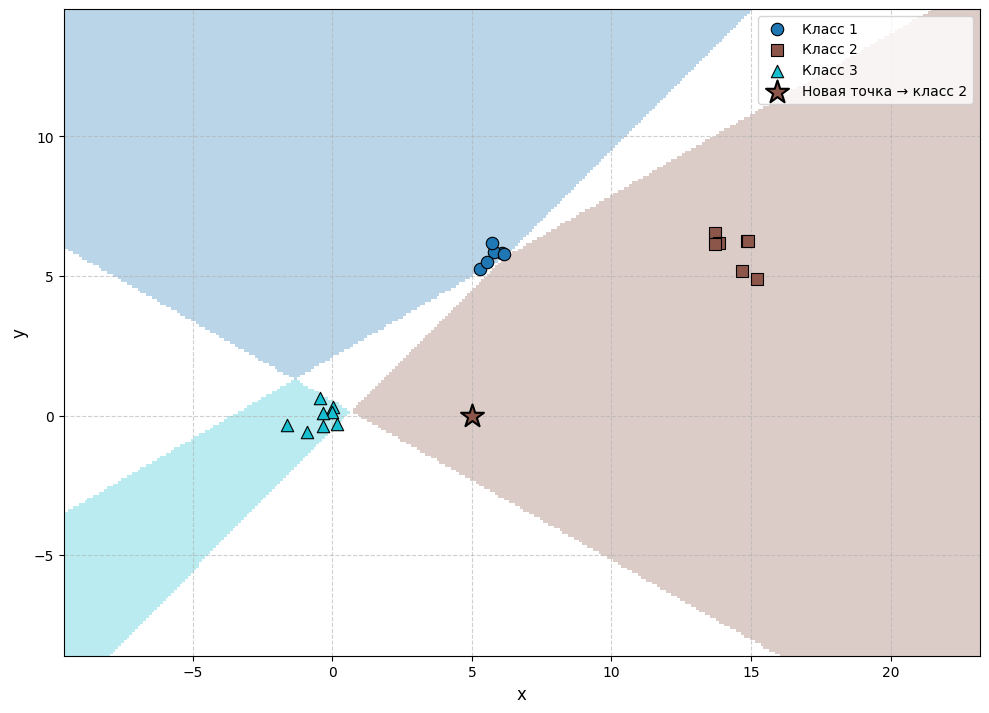

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math

x_coords = np.array([5.28, 6.09, 5.81, 6.14, 5.73, 5.53,
                     15.20, 13.70, 14.84, 13.85, 14.88, 13.70, 14.66,
                     -1.62, 0.03, 0.18, -0.89, 0.00, -0.32, -0.33, -0.45])
y_coords = np.array([5.26, 5.83, 5.86, 5.80, 6.17, 5.50,
                     4.88, 6.55, 6.25, 6.18, 6.26, 6.15, 5.17,
                     -0.32, 0.31, -0.31, -0.60, 0.12, 0.09, -0.37, 0.63])

labels = np.array([1]*6 + [2]*7 + [3]*8)

data = list(zip(x_coords, y_coords, labels))

# ------------------------------
# Функции линейного классификатора
# ------------------------------
def dot(w, x):
    return w[0]*x[0] + w[1]*x[1] + w[2]*x[2]

def neuron(w, target_class, data):

    w = w.copy()
    all_correct = False
    while not all_correct:
        all_correct = True
        for (xi, yi, li) in data:
            x_vec = [xi, yi, 1.0]
            output = dot(w, x_vec)
            is_target = (li == target_class)
            if is_target:
                if output <= 0:
                    all_correct = False
                    norm2 = xi*xi + yi*yi + 1.0
                    C = math.ceil(abs(output) / norm2)
                    w[0] += C * xi
                    w[1] += C * yi
                    w[2] += C * 1.0
            else:
                if output >= 0:
                    all_correct = False
                    norm2 = xi*xi + yi*yi + 1.0
                    C = math.ceil(abs(output) / norm2)
                    w[0] -= C * xi
                    w[1] -= C * yi
                    w[2] -= C * 1.0
    return w

# ------------------------------
# Обуч
# ------------------------------
W_init = [
    [1.0, 2.0, 3.0],
    [2.0, 1.0, 3.0],
    [3.0, 1.0, 2.0]
]
W = []
for k in range(3):
    W.append(neuron(W_init[k], k+1, data))

print("=== Обученные весовые векторы (дискриминантные функции) ===")
for k in range(3):
    print(f"  W{k+1} = [{W[k][0]:.6f}, {W[k][1]:.6f}, {W[k][2]:.6f}]")

# ------------------------------
# Классификация тестовой точки
# ------------------------------
px_input = input("Введите координату X для новой точки: ")
py_input = input("Введите координату Y для новой точки: ")
px = float(px_input.replace(',', '.')) if px_input else 0.0
py = float(py_input.replace(',', '.')) if py_input else 0.0
test_vec = [px, py, 1.0]
s = [dot(W[0], test_vec), dot(W[1], test_vec), dot(W[2], test_vec)]

print("\n=== Значения дискриминантных функций для точки (0,0) ===")
for k in range(3):
    print(f"  s{k+1} = {s[k]:.6f}")

positive = []
if s[0] > 0: positive.append(1)
if s[1] > 0: positive.append(2)
if s[2] > 0: positive.append(3)

if len(positive) == 1:
    pred_class = positive[0]
    print(f"\nТочка (0,0) однозначно классифицирована как класс {pred_class}")
else:
    pred_class = 0
    print(f"\nТочка (0,0) не может быть однозначно классифицирована (положительных ответов: {len(positive)})")

# ------------------------------
# Построение сетки предсказаний
# ------------------------------
x_min = np.min(x_coords) - 8.0
x_max = np.max(x_coords) + 8.0
y_min = np.min(y_coords) - 8.0
y_max = np.max(y_coords) + 8.0

step = 0.1
nx = int((x_max - x_min) / step) + 1
ny = int((y_max - y_min) / step) + 1

Z = np.zeros((ny, nx), dtype=int)

for i in range(ny):
    yc = y_min + i * step
    for j in range(nx):
        xc = x_min + j * step
        vec = [xc, yc, 1.0]
        s1 = dot(W[0], vec)
        s2 = dot(W[1], vec)
        s3 = dot(W[2], vec)
        pos = []
        if s1 > 0: pos.append(1)
        if s2 > 0: pos.append(2)
        if s3 > 0: pos.append(3)
        if len(pos) == 1:
            Z[i, j] = pos[0]
        else:
            Z[i, j] = 0

# ------------------------------
# Визуализация
# ------------------------------
colors = plt.cm.tab10(np.linspace(0, 1, 3))
cmap = ListedColormap(['white'] + [colors[i] for i in range(3)])

fig, ax = plt.subplots(figsize=(10, 8))

x_vals = np.linspace(x_min, x_max, nx)
y_vals = np.linspace(y_min, y_max, ny)
X_grid, Y_grid = np.meshgrid(x_vals, y_vals)
ax.pcolormesh(X_grid, Y_grid, Z, shading='auto', cmap=cmap, alpha=0.3, edgecolors='none')

# Точки данных
for c, marker, label in zip([1,2,3], ['o','s','^'], ['Класс 1', 'Класс 2', 'Класс 3']):
    mask = (labels == c)
    ax.scatter(x_coords[mask], y_coords[mask], c=colors[c-1], marker=marker,
               edgecolors='black', linewidths=0.8, s=80, zorder=3, label=label)

# Тестовая точка
if pred_class != 0:
    ax.scatter(px, py, c=colors[pred_class-1], marker='*', s=300,
               edgecolors='black', linewidths=1.5, zorder=5,
               label=f'Новая точка → класс {pred_class}')
else:
    ax.scatter(px, py, c='black', marker='*', s=300,
               edgecolors='black', linewidths=1.5, zorder=5,
               label='Новая точка не классиф.')

ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.axis('scaled')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

handles, labels_legend = ax.get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()